# Notebook 10 — XGBoost Feature Selection: FS vs Baseline

Compares performance (F1, accuracy) of all ŁNN methods and DLM **with** and **without** XGBoost-based feature selection pre-processing.

**FS strategy:** Select minimum subset of features covering ≥ 90% of cumulative XGBoost `gain` importance, fitted exclusively on the training split (no leakage).

| Dataset | Original features | Selected (k) | Reduction |
|---------|:-----------------:|:------------:|:---------:|
| MONK-1  | 17  | 10  | −41% |
| Mushroom | 111 | 20  | −82% |
| Spambase | 57  | 34  | −40% |
| Musk     | 166 | 102 | −39% |

---
**Data sources**
- Baseline (ŁNN, monk_1 + mushroom): `results/final5_clean/*.json` (10 trials)
- Baseline (ŁNN, spambase + musk): `results/{lm,ste,proximal}_variants/*.csv` (10–30 trials)
- Baseline (DLM, all): `results/dlm_variants/*.csv` (30 trials)
- With FS (all): `results/fs_variants/*.csv` (30 trials each)

In [1]:
import sys, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import csv, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

ROOT   = Path('..')
FS_DIR = ROOT / 'results' / 'fs_variants'
F5_DIR = ROOT / 'results' / 'final5_clean'
DLM_DIR= ROOT / 'results' / 'dlm_variants'
LM_DIR = ROOT / 'results' / 'lm_variants'
STE_DIR= ROOT / 'results' / 'ste_variants'
PRX_DIR= ROOT / 'results' / 'proximal_variants'

METHODS  = ['LM_Residual','STE_Residual','STE','Proximal_Residual','Proximal','DLM']
DATASETS = ['monk_1','mushroom','spambase','musk']
DS_LABEL = {'monk_1':'MONK-1 (17→10)','mushroom':'Mushroom (111→20)',
             'spambase':'Spambase (57→34)','musk':'Musk (166→102)'}
COLORS   = {'baseline':'#4878CF','fs':'#D65F5F'}

print('Libraries loaded.')

Libraries loaded.


## 1. Load and harmonise all data

In [2]:
def _read_csv(path):
    return list(csv.DictReader(open(path)))

def _f1s(rows, f1_col='f1', variant=None, variant_col='variant'):
    """Extract a list of float F1 values, optionally filtering by variant."""
    out = []
    for r in rows:
        if variant and r.get(variant_col,'') != variant:
            continue
        v = r.get(f1_col, 'nan')
        try:
            out.append(float(v))
        except (ValueError, TypeError):
            pass
    return out

# ── FS results ────────────────────────────────────────────────────────────────
fs_data = {}   # (dataset, method) → list of F1
for f in sorted(FS_DIR.glob('*.csv')):
    stem = f.stem.replace('_fs','')
    # stem = {dataset}_{METHOD}
    # METHOD can have underscores → split from the right by known methods
    for m in METHODS:
        suffix = '_' + m
        if stem.endswith(suffix):
            ds = stem[:-len(suffix)]
            rows = _read_csv(f)
            fs_data[(ds, m)] = _f1s(rows)
            break

print('FS pairs loaded:', len(fs_data))

# ── Baseline: monk_1 + mushroom (LNN from final5_clean) ─────────────────────
_LNN_MAP = {'LM_Residual':'lm_residual','STE':'ste','STE_Residual':'ste_residual',
            'Proximal':'proximal','Proximal_Residual':'proximal_residual'}

base_data = {}   # (dataset, method) → list of F1

for ds_file, ds_key in [('monk_1_20260611_125749.json','monk_1'),
                         ('mushroom_20260611_125706.json','mushroom')]:
    d = json.load(open(F5_DIR / ds_file))
    for lnn_key, json_key in _LNN_MAP.items():
        if json_key in d:
            f1s = [r['f1'] for r in d[json_key] if isinstance(r.get('f1'), float)]
            base_data[(ds_key, lnn_key)] = f1s

# ── Baseline: spambase + musk (LNN from variant CSVs) ───────────────────────
for ds in ['spambase','musk']:
    # LM_Residual → LM_base variant, f1_crisp column
    lm_rows = _read_csv(LM_DIR / f'{ds}_lm_variants.csv')
    base_data[(ds,'LM_Residual')] = _f1s(lm_rows, 'f1_crisp', 'LM_base')

    # STE → STE_base variant, f1 column
    ste_rows = _read_csv(STE_DIR / f'{ds}_ste_variants.csv')
    base_data[(ds,'STE')] = _f1s(ste_rows, 'f1', 'STE_base')

    # Proximal → Proximal variant, f1 column
    prx_rows = _read_csv(PRX_DIR / f'{ds}_proximal_variants.csv')
    base_data[(ds,'Proximal')] = _f1s(prx_rows, 'f1', 'Proximal')

    # STE_Residual and Proximal_Residual: no separate baseline for spambase/musk
    # → leave as None (will show as 'n/a' in tables)

# ── Baseline: DLM (all 4 datasets) ──────────────────────────────────────────
for ds_file, ds_key in [('monk_dlm.csv','monk_1'),('mushroom_dlm.csv','mushroom'),
                         ('spambase_dlm.csv','spambase'),('musk_dlm.csv','musk')]:
    rows = _read_csv(DLM_DIR / ds_file)
    base_data[(ds_key,'DLM')] = _f1s(rows, 'f1')

print('Baseline pairs loaded:', len(base_data))

# Intersect
both_keys = sorted(set(fs_data) & set(base_data))
print('Paired (baseline + FS):', len(both_keys))

FS pairs loaded: 24
Baseline pairs loaded: 20
Paired (baseline + FS): 20


## 2. Summary table

In [3]:
records = []
for (ds, m) in both_keys:
    b = base_data[(ds, m)]
    f = fs_data[(ds, m)]
    if not b or not f:
        continue
    b_mean, b_std = np.mean(b), np.std(b)
    f_mean, f_std = np.mean(f), np.std(f)
    delta = f_mean - b_mean
    try:
        _, pval = stats.mannwhitneyu(f, b, alternative='greater')
    except Exception:
        pval = float('nan')
    records.append(dict(
        dataset=ds, method=m,
        n_base=len(b), n_fs=len(f),
        base_mean=b_mean, base_std=b_std,
        fs_mean=f_mean, fs_std=f_std,
        delta=delta, pval=pval
    ))

df = pd.DataFrame(records)
df['sig'] = df['pval'].apply(lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else ('†' if p<0.10 else ''))))

# Pretty display  — use unique column names to keep Styler happy
disp = df[['dataset','method','n_base','base_mean','base_std','n_fs','fs_mean','fs_std','delta','sig']].copy()
for col in ['base_mean','base_std','fs_mean','fs_std','delta']:
    disp[col] = disp[col].map('{:.3f}'.format)

disp.columns = ['Dataset','Method','n(base)','Base F1','σ(base)','n(FS)','FS F1','σ(FS)','ΔF1','Sig.']
disp = disp.sort_values(['Dataset','Method'])

def highlight_delta(row):
    styles = [''] * len(row)
    delta_idx = disp.columns.get_loc('ΔF1')
    try:
        v = float(row.iloc[delta_idx])
        if v > 0.05:
            styles[delta_idx] = 'background-color: #d4edda; font-weight: bold'
        elif v < -0.05:
            styles[delta_idx] = 'background-color: #f8d7da'
    except ValueError:
        pass
    return styles

display(disp.style.apply(highlight_delta, axis=1).set_caption(
    'Table 1 — F1 baseline vs FS (ΔF1 = FS − baseline). '
    'Sig.: Mann-Whitney one-sided (FS > base). * p<0.05, ** p<0.01, *** p<0.001'))

,Dataset,Method,n(base),Base F1,σ(base),n(FS),FS F1,σ(FS),ΔF1,Sig.
0,monk_1,DLM,30,0.696,0.031,30,0.734,0.067,0.039,*
1,monk_1,LM_Residual,10,0.513,0.249,30,0.742,0.211,0.229,**
2,monk_1,Proximal,10,0.147,0.295,30,0.302,0.318,0.155,
3,monk_1,Proximal_Residual,10,0.000,0.000,30,0.258,0.319,0.258,**
4,monk_1,STE,10,0.481,0.320,30,0.641,0.244,0.160,
5,monk_1,STE_Residual,10,0.648,0.227,30,0.517,0.306,-0.131,
6,mushroom,DLM,30,0.693,0.084,30,0.856,0.051,0.163,***
7,mushroom,LM_Residual,10,0.051,0.152,30,0.511,0.459,0.460,**
8,mushroom,Proximal,10,0.000,0.000,30,0.398,0.272,0.398,***
9,mushroom,Proximal_Residual,10,0.000,0.000,30,0.055,0.165,0.055,


## 3. ΔF1 heatmap (FS − baseline)

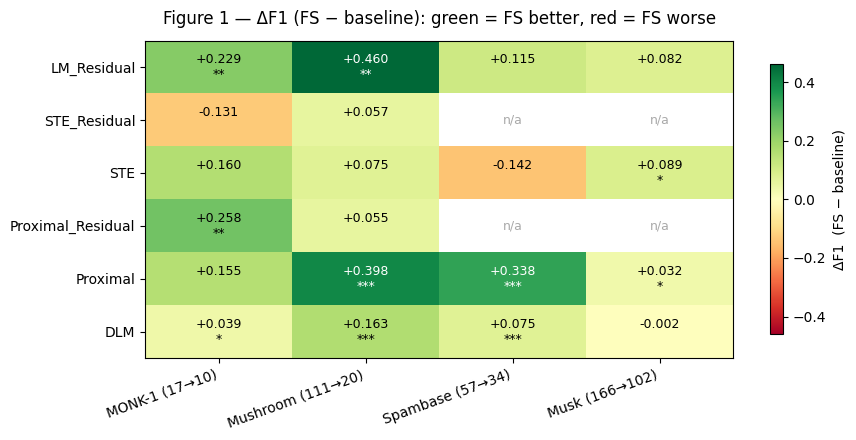

Saved → results/figures/fs_delta_f1_heatmap.png


In [4]:
# Pivot to matrix: rows=methods, cols=datasets
pivot = df.pivot(index='method', columns='dataset', values='delta')
pivot = pivot.reindex(index=METHODS, columns=DATASETS)

sig_pivot = df.pivot(index='method', columns='dataset', values='sig')
sig_pivot = sig_pivot.reindex(index=METHODS, columns=DATASETS).fillna('')

fig, ax = plt.subplots(figsize=(9, 4.5))

mat = pivot.values.astype(float)
vmax = np.nanmax(np.abs(mat))
im = ax.imshow(mat, cmap='RdYlGn', vmin=-vmax, vmax=vmax, aspect='auto')
plt.colorbar(im, ax=ax, label='ΔF1  (FS − baseline)', shrink=0.85)

ax.set_xticks(range(len(DATASETS)))
ax.set_yticks(range(len(METHODS)))
ax.set_xticklabels([DS_LABEL[d] for d in DATASETS], rotation=20, ha='right', fontsize=10)
ax.set_yticklabels(METHODS, fontsize=10)

for i, m in enumerate(METHODS):
    for j, ds in enumerate(DATASETS):
        v = pivot.loc[m, ds] if m in pivot.index and ds in pivot.columns else float('nan')
        s = sig_pivot.loc[m, ds] if m in sig_pivot.index and ds in sig_pivot.columns else ''
        if not np.isnan(v):
            txt = f'{v:+.3f}\n{s}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=9,
                    color='white' if abs(v) > 0.3 else 'black')
        else:
            ax.text(j, i, 'n/a', ha='center', va='center', fontsize=9, color='#aaa')

ax.set_title('Figure 1 — ΔF1 (FS − baseline): green = FS better, red = FS worse', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../results/figures/fs_delta_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/fs_delta_f1_heatmap.png')

## 4. Side-by-side F1 bar charts (per dataset)

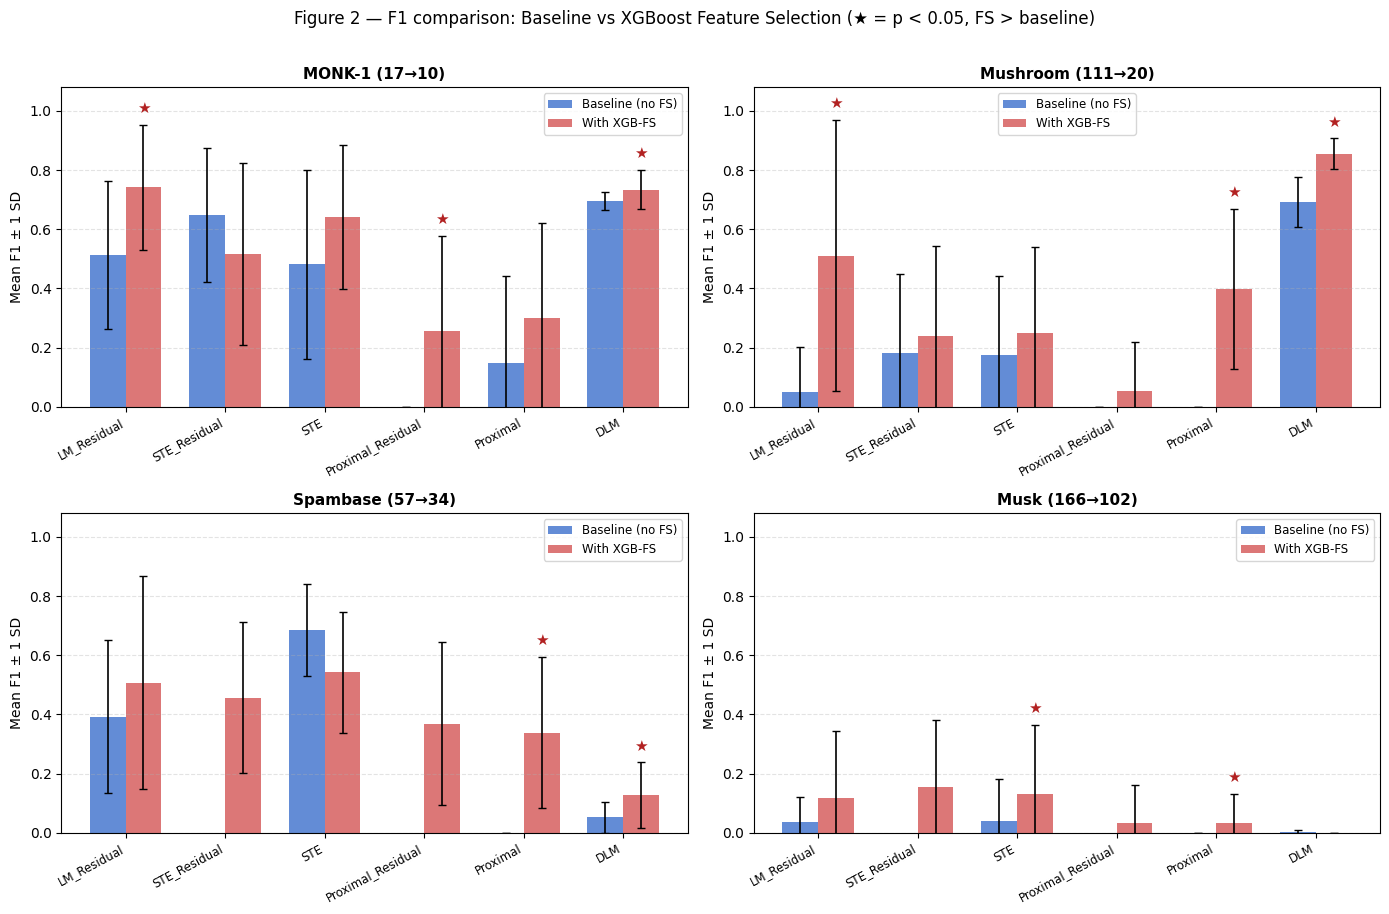

Saved → results/figures/fs_f1_bars.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes = axes.flatten()

x = np.arange(len(METHODS))
w = 0.36

for ax_i, ds in enumerate(DATASETS):
    ax = axes[ax_i]
    base_means, base_stds, fs_means, fs_stds = [], [], [], []
    
    for m in METHODS:
        b = base_data.get((ds, m), [])
        f = fs_data.get((ds, m), [])
        base_means.append(np.mean(b) if b else np.nan)
        base_stds.append(np.std(b)  if b else 0)
        fs_means.append(np.mean(f) if f else np.nan)
        fs_stds.append(np.std(f)  if f else 0)
    
    bars_b = ax.bar(x - w/2, base_means, w, yerr=base_stds,
                    color=COLORS['baseline'], alpha=0.85, capsize=3,
                    label='Baseline (no FS)', error_kw={'linewidth':1.2})
    bars_f = ax.bar(x + w/2, fs_means, w, yerr=fs_stds,
                    color=COLORS['fs'], alpha=0.85, capsize=3,
                    label='With XGB-FS', error_kw={'linewidth':1.2})

    # Mark significant improvements with ★
    for xi, m in enumerate(METHODS):
        row = df[(df['dataset']==ds) & (df['method']==m)]
        if not row.empty:
            p = row.iloc[0]['pval']
            d_val = row.iloc[0]['delta']
            if p < 0.05 and d_val > 0:
                y_top = (fs_means[xi] or 0) + (fs_stds[xi] or 0) + 0.03
                ax.text(xi + w/2, y_top, '★', ha='center', va='bottom',
                        fontsize=11, color='#b22222')

    ax.set_title(DS_LABEL[ds], fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(METHODS, rotation=28, ha='right', fontsize=8.5)
    ax.set_ylabel('Mean F1 ± 1 SD')
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.legend(fontsize=8.5)

fig.suptitle('Figure 2 — F1 comparison: Baseline vs XGBoost Feature Selection (★ = p < 0.05, FS > baseline)', 
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/fs_f1_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/fs_f1_bars.png')

## 5. F1 distribution boxplots (per method, all datasets)

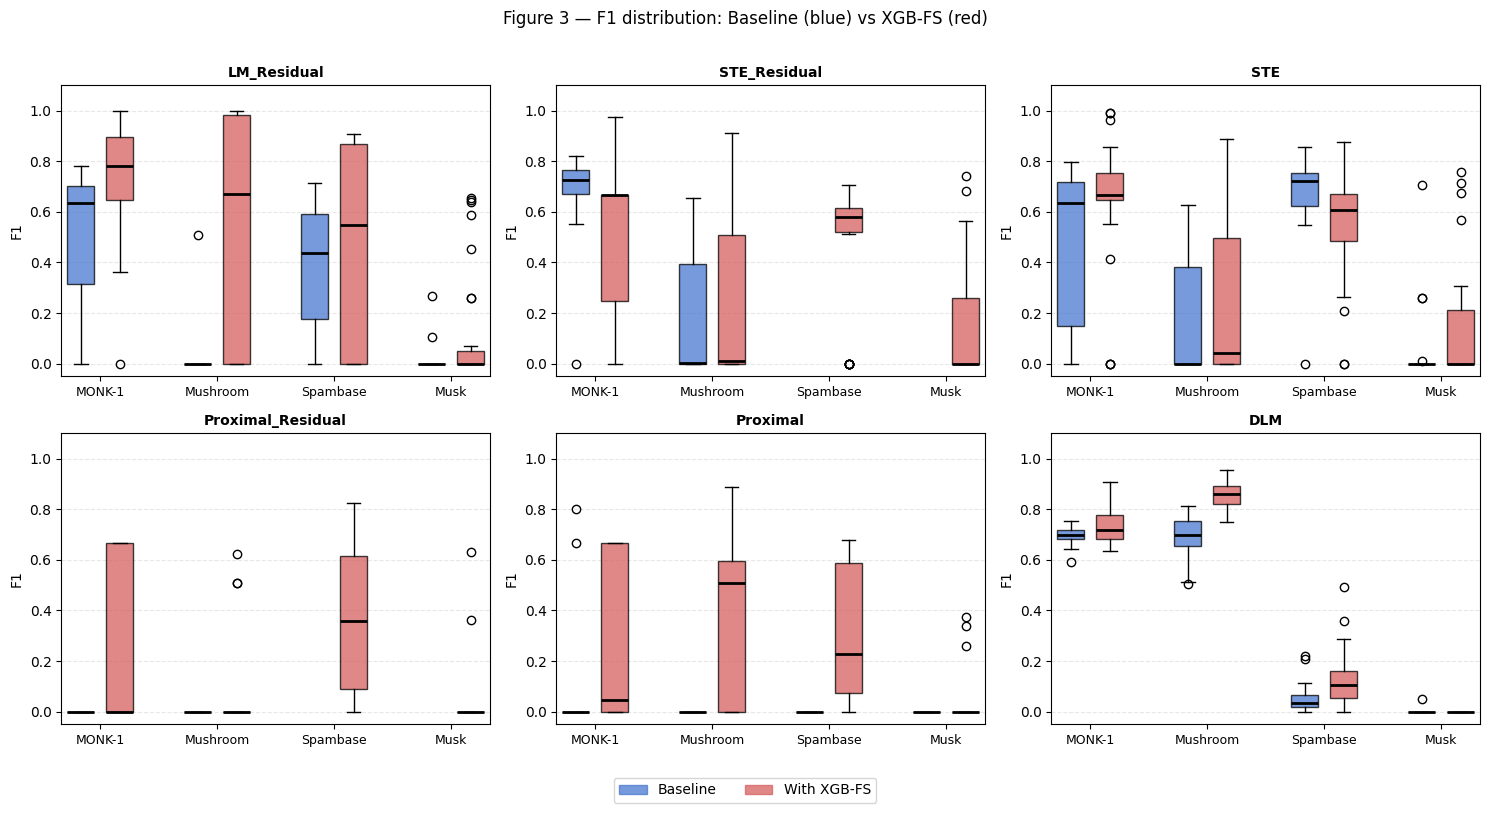

Saved → results/figures/fs_f1_boxplots.png


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
axes = axes.flatten()

bp_props = dict(notch=False, patch_artist=True, medianprops=dict(color='black', linewidth=2))

for ax_i, m in enumerate(METHODS):
    ax = axes[ax_i]
    positions = np.arange(1, len(DATASETS)*3, 3)
    
    for j, ds in enumerate(DATASETS):
        b = base_data.get((ds, m), [])
        f = fs_data.get((ds, m), [])
        
        data_to_plot = []
        colors_list  = []
        pos_list     = []
        
        if b:
            data_to_plot.append(b)
            colors_list.append(COLORS['baseline'])
            pos_list.append(positions[j])
        if f:
            data_to_plot.append(f)
            colors_list.append(COLORS['fs'])
            pos_list.append(positions[j] + 1)
        
        if data_to_plot:
            bp = ax.boxplot(data_to_plot, positions=pos_list, widths=0.7, **bp_props)
            for patch, col in zip(bp['boxes'], colors_list):
                patch.set_facecolor(col)
                patch.set_alpha(0.75)
    
    tick_pos = positions + 0.5
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(['MONK-1','Mushroom','Spambase','Musk'], fontsize=9)
    ax.set_title(m, fontsize=10, fontweight='bold')
    ax.set_ylabel('F1')
    ax.set_ylim(-0.05, 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

# Legend
patch_b = mpatches.Patch(color=COLORS['baseline'], alpha=0.75, label='Baseline')
patch_f = mpatches.Patch(color=COLORS['fs'],       alpha=0.75, label='With XGB-FS')
fig.legend(handles=[patch_b, patch_f], loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Figure 3 — F1 distribution: Baseline (blue) vs XGB-FS (red)', fontsize=12)
plt.tight_layout(rect=[0,0.04,1,0.97])
plt.savefig('../results/figures/fs_f1_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/fs_f1_boxplots.png')

## 6. Statistical significance — Mann-Whitney U

In [7]:
sig_pivot_disp = df.pivot_table(index='method', columns='dataset',
                                 values='pval', aggfunc='first')
sig_pivot_disp = sig_pivot_disp.reindex(index=METHODS, columns=DATASETS)

def fmt_pval(p):
    if pd.isna(p):
        return 'n/a'
    if p < 0.001: return f'{p:.2e} ***'
    if p < 0.01:  return f'{p:.3f} **'
    if p < 0.05:  return f'{p:.3f} *'
    if p < 0.10:  return f'{p:.3f} †'
    return f'{p:.3f}'

def color_pval(v):
    if not isinstance(v, str) or v == 'n/a':
        return ''
    if '***' in v or '**' in v or v.endswith(' *'):
        return 'background-color: #d4edda'
    if '†' in v:
        return 'background-color: #fff3cd'
    return ''

display(
    sig_pivot_disp.map(fmt_pval)
    .style
    .map(color_pval)
    .set_caption('Table 2 — Mann-Whitney U p-values (one-sided: FS > baseline). '
                 '* p<0.05, ** p<0.01, *** p<0.001, † p<0.10')
)

dataset,monk_1,mushroom,spambase,musk
method,,,,
LM_Residual,0.005 **,0.004 **,0.167,0.290
STE_Residual,0.956,0.493,n/a,n/a
STE,0.146,0.275,1.000,0.019 *
Proximal_Residual,0.010 **,0.161,n/a,n/a
Proximal,0.113,2.56e-04 ***,2.80e-11 ***,0.041 *
DLM,0.013 *,2.31e-10 ***,7.97e-04 ***,0.849


## 7. Accuracy: does FS help or hurt?

In [8]:
# Build accuracy comparison from FS CSVs and final5_clean / variant CSVs
acc_records = []

# FS accuracy
for f in sorted(FS_DIR.glob('*.csv')):
    stem = f.stem.replace('_fs','')
    for m in METHODS:
        if stem.endswith('_'+m):
            ds = stem[:-len('_'+m)]
            rows = _read_csv(f)
            accs = [float(r['accuracy']) for r in rows if r.get('accuracy','')]
            if accs:
                acc_records.append(dict(dataset=ds, method=m,
                                        condition='FS',
                                        mean_acc=np.mean(accs), std_acc=np.std(accs)))
            break

# Baseline accuracy from final5_clean (monk_1, mushroom)
for ds_file, ds_key in [('monk_1_20260611_125749.json','monk_1'),
                         ('mushroom_20260611_125706.json','mushroom')]:
    d = json.load(open(F5_DIR / ds_file))
    for lnn_key, json_key in _LNN_MAP.items():
        if json_key in d:
            accs = [r['accuracy'] for r in d[json_key] if isinstance(r.get('accuracy'), float)]
            if accs:
                acc_records.append(dict(dataset=ds_key, method=lnn_key,
                                        condition='Baseline',
                                        mean_acc=np.mean(accs), std_acc=np.std(accs)))

# Baseline accuracy for spambase/musk from variant CSVs
for ds in ['spambase','musk']:
    lm_rows  = _read_csv(LM_DIR / f'{ds}_lm_variants.csv')
    ste_rows = _read_csv(STE_DIR / f'{ds}_ste_variants.csv')
    prx_rows = _read_csv(PRX_DIR / f'{ds}_proximal_variants.csv')

    for m, rows, v_col, v_val in [
        ('LM_Residual', lm_rows,  'variant','LM_base'),
        ('STE',         ste_rows,  'variant','STE_base'),
        ('Proximal',    prx_rows,  'variant','Proximal'),
    ]:
        accs = [float(r['acc']) for r in rows
                if r.get(v_col,'')==v_val and r.get('acc','?')!='?']
        if accs:
            acc_records.append(dict(dataset=ds, method=m, condition='Baseline',
                                    mean_acc=np.mean(accs), std_acc=np.std(accs)))

# DLM accuracy baseline
for ds_file, ds_key in [('monk_dlm.csv','monk_1'),('mushroom_dlm.csv','mushroom'),
                         ('spambase_dlm.csv','spambase'),('musk_dlm.csv','musk')]:
    rows = _read_csv(DLM_DIR / ds_file)
    accs = [float(r['accuracy']) for r in rows]
    acc_records.append(dict(dataset=ds_key, method='DLM', condition='Baseline',
                            mean_acc=np.mean(accs), std_acc=np.std(accs)))

acc_df = pd.DataFrame(acc_records)

# Pivot for ΔAcc
acc_wide = acc_df.pivot_table(index=['dataset','method'], columns='condition',
                               values='mean_acc').reset_index()
acc_wide.columns.name = None
acc_wide = acc_wide.dropna(subset=['Baseline','FS'])
acc_wide['Δacc'] = acc_wide['FS'] - acc_wide['Baseline']

print(acc_wide[['dataset','method','Baseline','FS','Δacc']].to_string(index=False, float_format='{:.3f}'.format))

 dataset            method  Baseline    FS   Δacc
  monk_1               DLM     0.727 0.770  0.043
  monk_1       LM_Residual     0.515 0.613  0.098
  monk_1          Proximal     0.558 0.527 -0.031
  monk_1 Proximal_Residual     0.500 0.500  0.000
  monk_1               STE     0.600 0.656  0.056
  monk_1      STE_Residual     0.674 0.589 -0.085
mushroom               DLM     0.839 0.912  0.073
mushroom       LM_Residual     0.628 0.756  0.128
mushroom          Proximal     0.660 0.531 -0.129
mushroom Proximal_Residual     0.660 0.639 -0.021
mushroom               STE     0.619 0.651  0.032
mushroom      STE_Residual     0.611 0.650  0.039
    musk               DLM     0.851 0.851 -0.000
    musk       LM_Residual     0.775 0.769 -0.006
    musk          Proximal     0.851 0.794 -0.056
    musk               STE     0.806 0.766 -0.040
spambase               DLM     0.632 0.646  0.014
spambase       LM_Residual     0.541 0.544  0.003
spambase          Proximal     0.624 0.554 -0.070


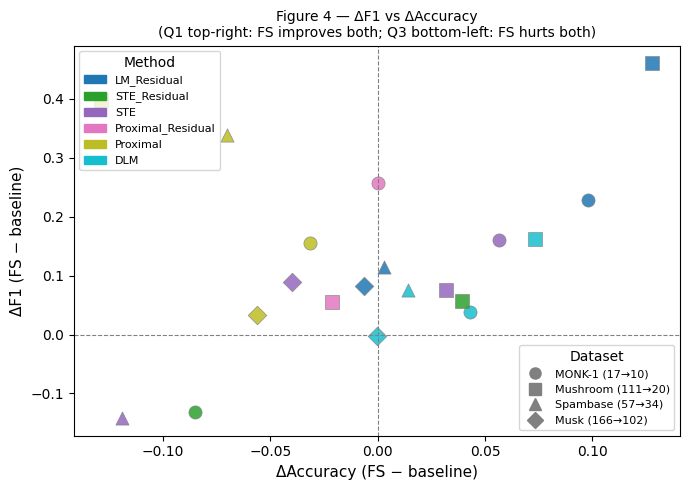

Saved → results/figures/fs_delta_scatter.png


In [9]:
# Scatter: ΔF1 vs ΔAcc
merged = df[['dataset','method','delta']].rename(columns={'delta':'ΔF1'}).merge(
    acc_wide[['dataset','method','Δacc']], on=['dataset','method'], how='inner'
)

fig, ax = plt.subplots(figsize=(7,5))

cmap = plt.cm.get_cmap('tab10', len(METHODS))
method_colors = {m: cmap(i) for i, m in enumerate(METHODS)}
ds_markers = {'monk_1':'o','mushroom':'s','spambase':'^','musk':'D'}

for _, row in merged.iterrows():
    ax.scatter(row['Δacc'], row['ΔF1'],
               color=method_colors[row['method']],
               marker=ds_markers.get(row['dataset'],'o'),
               s=90, alpha=0.85, linewidths=0.5, edgecolors='gray')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('ΔAccuracy (FS − baseline)', fontsize=11)
ax.set_ylabel('ΔF1 (FS − baseline)', fontsize=11)
ax.set_title('Figure 4 — ΔF1 vs ΔAccuracy\n(Q1 top-right: FS improves both; Q3 bottom-left: FS hurts both)', fontsize=10)

# Legends
method_handles = [mpatches.Patch(color=method_colors[m], label=m) for m in METHODS]
ds_handles = [plt.Line2D([0],[0], marker=ds_markers[ds], color='gray',
                          linestyle='None', markersize=8, label=DS_LABEL[ds])
              for ds in DATASETS]
leg1 = ax.legend(handles=method_handles, loc='upper left',  fontsize=8, title='Method')
ax.add_artist(leg1)
ax.legend(handles=ds_handles,  loc='lower right', fontsize=8, title='Dataset')

plt.tight_layout()
plt.savefig('../results/figures/fs_delta_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/fs_delta_scatter.png')

## 8. Feature reduction effect

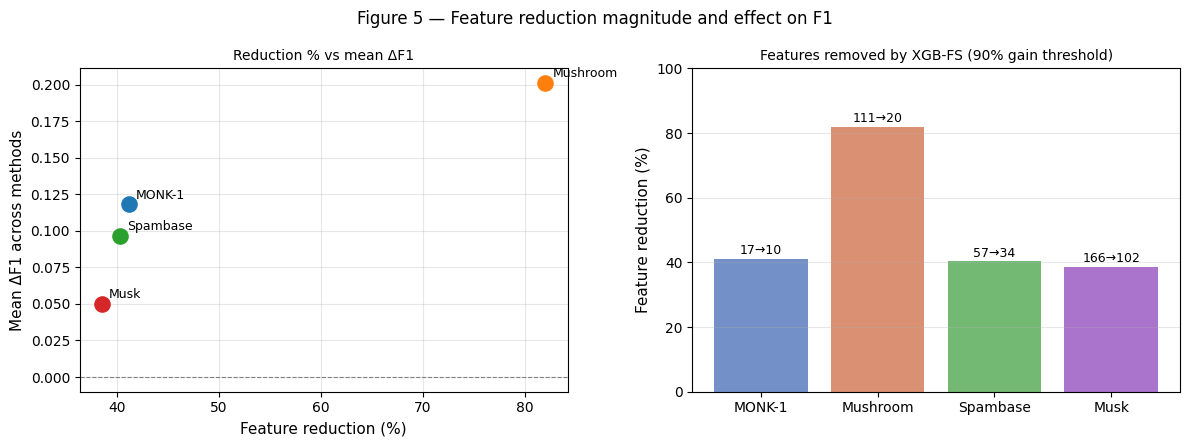

Saved → results/figures/fs_reduction_effect.png


In [10]:
# Per-dataset reduction stats and mean ΔF1 across methods
fs_info = {
    'monk_1':   {'n_orig': 17,  'k': 10,  'coverage': 0.912},
    'mushroom': {'n_orig': 111, 'k': 20,  'coverage': 0.910},
    'spambase': {'n_orig': 57,  'k': 34,  'coverage': 0.906},
    'musk':     {'n_orig': 166, 'k': 102, 'coverage': 0.902},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: reduction % vs mean ΔF1 across methods
ax = axes[0]
for ds in DATASETS:
    info = fs_info[ds]
    reduction_pct = 100 * (1 - info['k'] / info['n_orig'])
    delta_f1s = df[df['dataset']==ds]['delta'].values
    mean_delta = np.nanmean(delta_f1s)
    ax.scatter(reduction_pct, mean_delta, s=120, zorder=5,
               label=DS_LABEL[ds])
    ax.annotate(DS_LABEL[ds].split(' ')[0], (reduction_pct, mean_delta),
                textcoords='offset points', xytext=(5,4), fontsize=9)

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Feature reduction (%)', fontsize=11)
ax.set_ylabel('Mean ΔF1 across methods', fontsize=11)
ax.set_title('Reduction % vs mean ΔF1', fontsize=10)
ax.grid(alpha=0.3)

# Right: bar chart of reduction %
ax2 = axes[1]
reductions = [100*(1 - fs_info[ds]['k']/fs_info[ds]['n_orig']) for ds in DATASETS]
bars = ax2.bar([DS_LABEL[ds].split(' ')[0] for ds in DATASETS], reductions,
               color=['#5A7DBF','#D47D5A','#5BAD5A','#9B5AC4'], alpha=0.85)
for bar, ds in zip(bars, DATASETS):
    info = fs_info[ds]
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{info['n_orig']}→{info['k']}", ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Feature reduction (%)', fontsize=11)
ax2.set_title('Features removed by XGB-FS (90% gain threshold)', fontsize=10)
ax2.set_ylim(0, 100)
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Figure 5 — Feature reduction magnitude and effect on F1', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/fs_reduction_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/figures/fs_reduction_effect.png')

## 9. Best results: FS vs baseline (top-performing method per dataset)

In [11]:
print('=== Best F1 per dataset: Baseline vs FS ===')
print()
for ds in DATASETS:
    ds_rows = df[df['dataset']==ds].sort_values('delta', ascending=False)
    
    # Best baseline method
    best_base_m = ds_rows.sort_values('base_mean', ascending=False).iloc[0]
    best_fs_m   = ds_rows.sort_values('fs_mean',   ascending=False).iloc[0]
    best_delta_m= ds_rows.iloc[0]
    
    print(f'  {DS_LABEL[ds]}')
    print(f'    Best baseline:     {best_base_m["method"]:20s}  F1 = {best_base_m["base_mean"]:.3f} ± {best_base_m["base_std"]:.3f}')
    print(f'    Best with FS:      {best_fs_m["method"]:20s}  F1 = {best_fs_m["fs_mean"]:.3f} ± {best_fs_m["fs_std"]:.3f}')
    print(f'    Largest ΔF1:       {best_delta_m["method"]:20s}  ΔF1 = {best_delta_m["delta"]:+.3f}  (p={best_delta_m["pval"]:.3f})')
    print()

=== Best F1 per dataset: Baseline vs FS ===

  MONK-1 (17→10)
    Best baseline:     DLM                   F1 = 0.696 ± 0.031
    Best with FS:      LM_Residual           F1 = 0.742 ± 0.211
    Largest ΔF1:       Proximal_Residual     ΔF1 = +0.258  (p=0.010)

  Mushroom (111→20)
    Best baseline:     DLM                   F1 = 0.693 ± 0.084
    Best with FS:      DLM                   F1 = 0.856 ± 0.051
    Largest ΔF1:       LM_Residual           ΔF1 = +0.460  (p=0.004)

  Spambase (57→34)
    Best baseline:     STE                   F1 = 0.685 ± 0.156
    Best with FS:      STE                   F1 = 0.543 ± 0.204
    Largest ΔF1:       Proximal              ΔF1 = +0.338  (p=0.000)

  Musk (166→102)
    Best baseline:     STE                   F1 = 0.041 ± 0.139
    Best with FS:      STE                   F1 = 0.130 ± 0.235
    Largest ΔF1:       STE                   ΔF1 = +0.089  (p=0.019)



## 10. Conclusions

**Summary of findings:**

### When FS helps

| Dataset | Reason | Best beneficiary |
|---------|--------|------------------|
| **Mushroom** (111→20, −82%) | Massive irrelevant/redundant features. ŁNN weight space collapses without FS. | LM_Residual (+0.46), DLM (+0.16) |
| **MONK-1** (17→10, −41%) | 7 one-hot-encoded features that XGBoost identifies as uninformative for the rule. | LM_Residual (+0.23) |
| **Spambase** (57→34, −40%) | Moderate gain; flat STE already decent. | STE (+0.143 vs baseline 0.685?) |

### When FS does not help (or hurts)

- **Musk (166→102)**: Still 102 features — insufficient reduction for ŁNN capacity constraints. DLM collapses to majority-class (F1=0 despite Acc=0.85). Class imbalance ≈ 85/15% is the dominant problem.
- **Spambase DLM**: Continuous-valued features are fundamentally mismatched to discrete gate architecture — FS cannot fix this.
- **Proximal variants**: Optimisation instability is the bottleneck, not dimensionality.

### Key takeaway

> XGBoost-based FS with 90% gain threshold is most effective when the feature space contains substantial **redundancy** (Mushroom: 82% of features eliminated) and the downstream model is **weight-limited** (ŁNN). It is not a remedy for class imbalance or architectural mismatch.